## Machine Learning Exercise 3: Bias and Variance

**Bias** refers to the error introduced by approximating a complex real-world problem with a simplified model, while **variance** refers to the model's sensitivity to fluctuations in the training data. A linear regression model has high bias and low variance; it makes strong assumptions about the data (linearity) but is stable across different datasets. If these strong assumptions are not correct, there will be places where it systematically overestimates or underestimates. In contrast, a decision tree model has low bias and high variance;it can capture complex patterns but is prone to overfitting, especially if deep and unpruned. This means that it can start to memorize the training data rather than capturing patterns that generalize.

In [14]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from sklearn import metrics

from sklearn.metrics import mean_squared_error

## conceptual note from class review:
* A model that has a big MSE difference between train and test data, means that the model likely "overfitted" to the training data. So it has more flexibility, but does not perform as equally when applied to new datasets ('test' dataset)

1. Fit a linear regression model to the housing data, using sqft_living to predict price. Check the mean squared error on the training data and the test data.

In [31]:
house_data= pd.read_csv('data/kc_house_data.csv')
house_data.head(3)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062


In [51]:
#set variables and prepare dataset
predict_var = ['sqft_living'] 
target_var= 'price'
X=pd.DataFrame(house_data[predict_var])
y= house_data[target_var]

#Make the model
x_train, x_test, y_train, y_test= train_test_split(X, 
                                                   y, 
                                                   test_size=0.3, 
                                                   random_state=321)

#Run linear regression
lin_model= LinearRegression().fit(x_train,y_train)

#Make predicitons from the test dataset
y_pred = lin_model.predict(x_test)
y_pred_train= lin_model.predict(x_train)

#Check mean squared error 
mse_test= mean_squared_error(y_test, y_pred)
#add it in scientific notation for easier comparing
print('test dataset MSE: ', format(mse_test, ".3e"))


mse_train= mean_squared_error(y_train, y_pred_train)
print('train dataset MSE: ', format(mse_train, ".3e"))

test dataset MSE:  6.608e+10
train dataset MSE:  6.933e+10


2. Repeat this but with a [DecisionTreeRegresor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html). Again check the mean squared error on the training data and the test data. How does what you see differ from the linear regression model?

In [35]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

In [36]:
#set variables and prepare dataset
predict_var = ['sqft_living'] 
target_var= 'price'
X=pd.DataFrame(house_data[predict_var])
y= house_data[target_var]

#Make the model
x_train, x_test, y_train, y_test= train_test_split(X, 
                                                   y, 
                                                   test_size=0.3, 
                                                   random_state=321)

In [37]:
tree_model= DecisionTreeRegressor(random_state=321).fit(x_train,y_train)
#cross_val_score(tree_model, X, y, cv=10)

#Make predicitons from the test dataset
y_pred = tree_model.predict(x_test)

#Check mean squared error 
mse_test= mean_squared_error(y_test, y_pred)
print('test dataset MSE: ', mse_test)

y_pred_train= tree_model.predict(x_train)
mse_train= mean_squared_error(y_train, y_pred_train)
print('train dataset MSE: ', mse_train)

test dataset MSE:  73538459276.97156
train dataset MSE:  50192955708.733604


**answer**: The tree regressor performed worse on the test dataset than the linear regression model, but better on the trained dataset [assuming lower MSE = better preformance]

One way of avoiding overfitting is by restricting the flexibility of the model. We can do this with a decision tree by restricting the number of splits that it can perform. 

3. Fit a DecisionTreeRegressor where you restrict the max_depth to 5. Again check the mean squared error on the training data and the test data. What do you notice now?

In [38]:
tree_model= DecisionTreeRegressor(random_state=321, max_depth=5).fit(x_train,y_train)
#cross_val_score(tree_model, X, y, cv=10)

#Make predicitons from the test dataset
y_pred = tree_model.predict(x_test)

#Check mean squared error 
mse_test= mean_squared_error(y_test, y_pred)
print('test dataset MSE: ', mse_test)

y_pred_train= tree_model.predict(x_train)
mse_train= mean_squared_error(y_train, y_pred_train)
print('train dataset MSE: ', mse_train)

test dataset MSE:  62926561451.64904
train dataset MSE:  60841449026.336685


**answer**: The max_depth tree regressor is much better with the test dataset than the basic tree regressor, but worse with the trained dataset. 

-----

When working with machine learning models, we often have to balance bias and variance. This is called the [bias-variance tradeoff](https://en.wikipedia.org/wiki/Bias%E2%80%93variance_tradeoff). One method of this is through [regularization](https://www.ibm.com/think/topics/regularization), where we restrict the complexity of the model, adding some bias but reducing the variance, which can lead to a lower mean squared error on the test set.

Lasso and ridge regression do this by adding a penalty term based on the size of the coefficients. Smaller coefficients means that the model has less flexibility. The neat thing about these types of models is that they determine how to allocate the coefficients automatically as part of the model fitting process, so we can start with a large set of potential predictors and allow the model fitting to determine which ones to focus on.

For the next part of the exercise, we'll see how we can add complexity to our model but control the complexity through regularization.

4. So far, we've only been predicting based off of the square footage of living space. Fit a new linear regression model using all variables besides id, date, price, and zipcode. How well does this model perform on the test set compared to the model with just square footage of living space?

In [39]:
#one model using all variables by assinging them as columns of the original dataframe
## 

In [44]:
X= house_data.drop(['id', 'date', 'price', 'zipcode'], axis=1)

In [54]:
#set variables and prepare dataset
X= house_data.drop(['id', 'date', 'price', 'zipcode'], axis=1)

target_var= 'price'
y= house_data[target_var]

#Make the model
x_train, x_test, y_train, y_test= train_test_split(X, 
                                                   y, 
                                                   test_size=0.3, 
                                                   random_state=321)

In [50]:
#Run linear regression
lin_model= LinearRegression().fit(x_train,y_train)

#Make predicitons from the test dataset
y_pred = lin_model.predict(x_test)

#Check mean squared error 
mse_test= mean_squared_error(y_test, y_pred)
#add it in scientific notation for easier comparing
print('test dataset MSE: ', format(mse_test, ".3e"))

y_pred_train= lin_model.predict(x_train)
mse_train= mean_squared_error(y_train, y_pred_train)
print('train dataset MSE: ', format(mse_train, ".3e"))

test dataset MSE:  4.176e+10
train dataset MSE:  4.080e+10


**answer**: The model with all variables performed better than the model with just the square living space, reducing the MSE.

* Previous model
    * test dataset MSE:  6.608e+10    * 
train dataset MSE:  6.933e+10

5. Try fitting a lasso and ridge model. Becuase lasso and ridge have penalty terms based on the size of the coefficients, and the size of the coefficients depends on the scale of the variable, you'll want to scale the features first so that they are on comparable scales. Create a [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) object where the first step is applying a [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) and the second step is either a lasso or ridge model. Because these models have a hyperparameter controlling regularization strength, you'll want to use the [LassoCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html) and [RidgeCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html) models, which will select values for the regularization strength using cross-validation.

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.datasets import make_regression
from sklearn.linear_model import RidgeCV

In [123]:
##pipeline object-> step 1) standard scaler -> step 2) LASSO(lassoCV) or RIDGE (RidgeCV)

#set variables and prepare dataset
X= house_data.drop(['id', 'date', 'price', 'zipcode'], axis=1)

target_var= 'price'
y= house_data[target_var]

#Make the model
x_train, x_test, y_train, y_test= train_test_split(X, 
                                                   y, 
                                                   test_size=0.3, 
                                                   random_state=321)

#pipline step one is the standard scaler, and the second step is applying the model 

lasso_pipe = Pipeline(
    steps=[
        ('scaler', StandardScaler()), 
        ('lasso', LassoCV())
    ])
ridge_pipe= Pipeline(
    [
        ('scaler', StandardScaler()), 
        ('lasso', RidgeCV())
    ])

In [124]:
##apply the model 
lasso_model= lasso_pipe.fit(x_train, y_train)

#Make predicitons from the test dataset
y_pred = lasso_model.predict(x_test)
y_pred_train= lasso_model.predict(x_train)

#Check mean squared error 
mse_test= mean_squared_error(y_test, y_pred)
#add it in scientific notation for easier comparing
print('test dataset MSE: ', format(mse_test, ".3e"))

mse_train= mean_squared_error(y_train, y_pred_train)
print('train dataset MSE: ', format(mse_train, ".3e"))

test dataset MSE:  4.177e+10
train dataset MSE:  4.081e+10


In [67]:
##apply the model 
ridge_model= ridge_pipe.fit(x_train, y_train)

#Make predicitons from the test dataset
y_pred = ridge_model.predict(x_test)
y_pred_train= ridge_model.predict(x_train)

#Check mean squared error 
mse_test= mean_squared_error(y_test, y_pred)
#add it in scientific notation for easier comparing
print('test dataset MSE: ', format(mse_test, ".3e"))

mse_train= mean_squared_error(y_train, y_pred_train)
print('train dataset MSE: ', format(mse_train, ".3e"))

test dataset MSE:  4.176e+10
train dataset MSE:  4.080e+10


You likely didn't see much difference between the regular linear regression model and the lasso or ridge model. Let's see what happens if we add more complexity through feature interactions. We can capture more complex relationships between the predictor variables and the target variable by multiplying the predictors together before fitting the model. For example, the interaction between sqft_living and bedrooms will let the model capture if the impact of square footage depends on the number of bedrooms.

6. Add [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) to your pipeline after the standard scaler. Try using degree 2 features. How does this change the performance of the regular linear regression model, the lasso model, and the ridge model? 

In [68]:
from sklearn.preprocessing import PolynomialFeatures

In [69]:
lasso_pipe = Pipeline([('scaler', StandardScaler()), 
                       ('polynom', PolynomialFeatures(2)),
                       ('lasso', LassoCV())])
ridge_pipe= Pipeline([('scaler', StandardScaler()), 
                      ('polynom', PolynomialFeatures(2)),
                      ('lasso', RidgeCV())])

In [70]:
##apply the model 
lasso_model= lasso_pipe.fit(x_train, y_train)

#Make predicitons from the test dataset
y_pred = lasso_model.predict(x_test)
y_pred_train= lasso_model.predict(x_train)

#Check mean squared error 
mse_test= mean_squared_error(y_test, y_pred)
#add it in scientific notation for easier comparing
print('test dataset MSE: ', format(mse_test, ".3e"))

mse_train= mean_squared_error(y_train, y_pred_train)
print('train dataset MSE: ', format(mse_train, ".3e"))

test dataset MSE:  2.514e+10
train dataset MSE:  2.635e+10


In [71]:
##apply the model 
ridge_model= ridge_pipe.fit(x_train, y_train)

#Make predicitons from the test dataset
y_pred = ridge_model.predict(x_test)
y_pred_train= ridge_model.predict(x_train)

#Check mean squared error 
mse_test= mean_squared_error(y_test, y_pred)
#add it in scientific notation for easier comparing
print('test dataset MSE: ', format(mse_test, ".3e"))

mse_train= mean_squared_error(y_train, y_pred_train)
print('train dataset MSE: ', format(mse_train, ".3e"))

test dataset MSE:  2.522e+10
train dataset MSE:  2.561e+10


**answer**: Applying the polynomial improved both the Lasso and Ridge models. Now there is also a slight difference between the model performance, with lasso model being slightly beter than the ridge model (2.51 vs 2.522)

The lasso penalty tends to cause some coeffients to zero out, so it can be viewed as a method of automatic feature selection.

7. Look at the set of coefficients for the lasso model. What percentage of the coefficients are zero? What are the largest non-zero coefficients?

In [120]:
#from scipy import stats

coef_values= lasso_model['lasso'].coef_
#stats.describe(coef_values)
print("percent zero: ", np.mean(coef_values == 0))
print("number zero: ", np.sum(coef_values == 0))

percent zero:  0.4853801169590643
number zero:  83


**answer** 48% of coefficents in the lasso model are equal to zero

In [121]:
print("percent non-zero: ", np.mean(coef_values != 0))
print("number non-zero: ", np.sum(coef_values != 0))

percent non-zero:  0.5146198830409356
number non-zero:  88


In [122]:
#lasso_model[:-1].get_feature_names_out()

In [96]:
coef_results= pd.DataFrame({'col_names':lasso_model[:-1].get_feature_names_out(), 
              'coeff':lasso_model['lasso'].coef_})

coef_results.sort_values('coeff')

,col_names,coeff
161,lat^2,-41215.451933
154,yr_built sqft_living15,-25451.428122
15,long,-23944.349431
132,grade long,-21063.775277
12,yr_built,-18549.691563
...,...,...
16,sqft_living15,38574.730072
57,sqft_living grade,39077.771105
14,lat,70301.434205
3,sqft_living,95077.950449


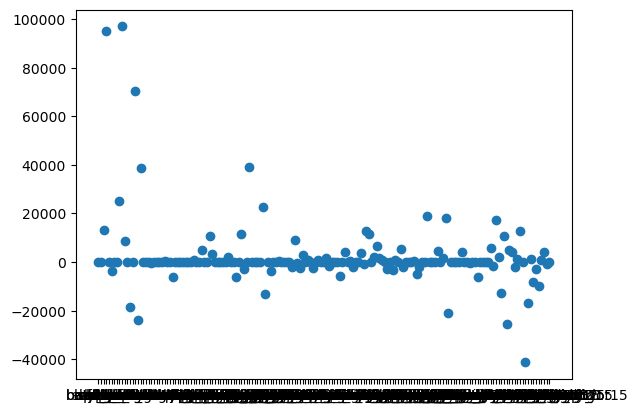

In [97]:
plt.scatter(coef_results['col_names'], coef_results['coeff']);

----

8. A new hyperparameter that we have is the degree of the polynomial we're using. So that we're not overfitting to the test set, we need to use cross-validation to select this value. Set up a [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) to try out polynomial degrees from 1 to 3 and to try LinearRegression, LassoCV, and RidgeCV models. Use 'neg_mean_squared_error' as the error_score. Which combination does it find does the best? 

----

** If you've reached this point, let your instructors know so that they can check in with you. **

Stretch Goals:

1. With home prices, there are some extremely large values for price, which can overly-influence the mean squared error calculation. See what happens if you optimize for mean absolute error instead. Alternatively, try using a [TransformedTargetRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html) to predict the log of price instead of the raw price.

**Bonus Exercise** We've seen how a decision tree model has move flexibility, which mean higher variance compared to a linear regression model. One way of understanding variance is that variance describes how sensitive the model is to the training data. A model with high variance can produce vastly different predictions when trained on different subsets.

In this bonus exercise, you'll get to see this in action.

Generate 1000 different linear regression fits, where you only use sqft_living as the predictor variable. For each fit, choose a random sample from the full dataset of size 1000. 
Using the np.linspace function, generate a grid of 100 equally-spaced points between 500 and 3000 and generate predictions on those points. Plot the mean prediction, the 5th percentile, and the 95th percentile for the predictions from these thousand models. Repeat this for a decision tree model. Then do it for a decision tree model with a max_depth of 5.

How do these predictions differ? Which have the most variability?